In [ ]:
# impostazione ambiente (Le versioni sono fissate per garantire compatibilità con gym-idsgame e ridurre problemi di breaking change tra librerie)

!pip install gym==0.26.2 -q
!pip install numpy==1.23.5 -q
!pip install torch -q
!pip install matplotlib
!git clone https://github.com/Limmen/gym-idsgame
%cd gym-idsgame

import numpy as np
import matplotlib.pyplot as plt
import random
import gym_idsgame
from gym_idsgame.envs.idsgame_env import IdsGameRandomAttackV21Env
from gym_idsgame.agents.bot_agents.random_attack_bot_agent import RandomAttackBotAgent
from gym_idsgame.envs.dao.game_config import GameConfig
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 12.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 83.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit co

In [ ]:
# inserimento riga di comando su script random_attack_bot_agent.py del repo GIT in quanto mancante dentro un metodo il comando "import idsgame_util":
!sed -i '1i from gym_idsgame.envs.util import idsgame_util' gym_idsgame/agents/bot_agents/random_attack_bot_agent.py

In [ ]:
import gym_idsgame.agents.bot_agents.random_attack_bot_agent as ra
env = IdsGameRandomAttackV21Env()
game_config = env.idsgame_config.game_config

In [ ]:
obs = env.reset()[0]

#Strategia adottata

Lo svelgimento del progetto è stato deciso sulle seguenti basi:
- il defender è l’agente addestrato
- l’attacker è un avversario fissato, definito all'interno della "repo".

La giustificazione di questo approccio sta nell'aver cercato e studiato la repo per capirne il contenuto. Poiché il progetto cita scenari di random e maximal attack, essendo questi disponibili direttamente tra gli agenti bot della repo, si è pensato di usare quelli.

# Parte 1: SARSA

Per SARSA: è stato deciso di usare una tabella Q perché lo spazio degli stati viene trattato in forma tabellare, con stato rappresentato come tupla del vettore osservazione.

Si è optato per la flattenizzazione dell'osservazione "obs", in modo da produrre una rappresentazione unidimensionale dello stato, necessaria per indicizzare la Q-table (altrimenti si va incontro ad errori)

Strategia epsilon-greedy: con probabilità epsilon esploro, altrimenti scelgo l'azione greedy.


In [ ]:
# -------------------------
# Q TABLE
# -------------------------
def initialize_q(env):
    n_actions = env.defender_action_space.n
    return defaultdict(lambda: np.zeros(n_actions, dtype=np.float32))


# -------------------------
# Strategia epsilon-greedy: con probabilità epsilon esploro, altrimenti scelgo l'azione greedy (versione di debug per verificare il tipo dello stato e l'accesso alla Q-table)
# -------------------------
def epsilon_greedy(Q, state, epsilon, n_actions):

    try:
        q_values = Q[state]
    except Exception as e:
        raise

    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)

    return int(np.argmax(q_values))

# -------------------------
# Update SARSA on-policy:
# aggiorno Q(s,a) usando l'azione effettivamente selezionata nello stato successivo.
# -------------------------

attacker = RandomAttackBotAgent(game_config, env)

def sarsa(env, alpha, gamma, epsilon, episodes, max_steps):

    Q = initialize_q(env)
    n_actions = env.defender_action_space.n
    SARSA_rewards = []
    td_errors = []

    for ep in range(episodes):

        obs = env.reset()[0]

        # inizializzazione stato
        state = tuple(obs.flatten())

        action = epsilon_greedy(Q, state, epsilon, n_actions)

        total_reward = 0

        for t in range(max_steps):

            attacker.convert_local_attacker_action_to_global(0, obs)
            attack_action = attacker.action


            next_obs, reward, terminated, truncated, info = env.step((attack_action, action))
            obs = next_obs
            done = terminated or truncated

            # reward maggiorata che penalizza le perdite e aggiunge bonus in caso di vittoria e sopravvivenza:
            base_reward = float(reward[0])
            win_reward = 0
            if env.state.hacked:
                win_reward = -3.0
            elif not env.state.hacked and terminated:
                win_reward = +1.0
            survival_bonus = 0.01
            reward = base_reward + win_reward + survival_bonus

            next_state = tuple(next_obs.flatten())
            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions)

            q_sa = Q[state][action]
            q_next = Q[next_state][next_action]

            # Aggiornamento SARSA

            Q[state][action] = q_sa + alpha * (reward + gamma * q_next - q_sa)

            td_errors.append(reward + gamma * q_next - q_sa) # utile per grafici

            state = next_state
            action = next_action
            obs = next_obs

            total_reward += reward

            if done:
              SARSA_rewards.append(total_reward)
              if ep % 500 == 0:
                print(f"Episode {ep}, episode reward is {total_reward}")
              break

    policy = {s: int(np.argmax(a)) for s, a in Q.items()}
    return Q, policy, SARSA_rewards, td_errors

La fase di evaluation non usa epsilon-greedy; il defender seleziona sempre l'azione con valore Q massimo.
Conteggio vittore: win-rate si basa sulla variabile "hacked" fornita dall'ambiente della repo GIT.

In [ ]:
def evaluate(env, Q, episodes=300, max_steps=30):

    wins = 0
    total_reward = 0


    for ep in range(episodes):
        obs = env.reset()[0]
        state = tuple(obs.flatten())
        done = False

        for st in range(max_steps):
            action = np.argmax(Q[state])  # NO epsilon

            attacker.convert_local_attacker_action_to_global(0, obs)
            attack_action = attacker.action

            next_obs, reward, terminated, truncated, _ = env.step((attack_action, action))
            obs = next_obs
            done = terminated or truncated

            next_state = tuple(next_obs.flatten())
            state = next_state

            reward = float(reward[0])   # baseline della repo GIT

            total_reward += reward

            if done:
                if env.state.hacked == False: # viene considerata come vittoria un episodio terminato senza hack del defender.
                    wins += 1
                    break

    return wins / episodes, total_reward / episodes

In [ ]:
import gym_idsgame.agents.bot_agents.random_attack_bot_agent as m
from gym_idsgame.agents.bot_agents.random_attack_bot_agent import RandomAttackBotAgent
import importlib
importlib.reload(m)

<module 'gym_idsgame.agents.bot_agents.random_attack_bot_agent' from '/content/gym-idsgame/gym_idsgame/agents/bot_agents/random_attack_bot_agent.py'>

In [ ]:
alpha = 0.1
gamma = 0.99
epsilon = 0.1
episodes = 5000
max_steps = 30

Q, policy, SARSA_rewards, td_errors = sarsa(env, alpha, gamma, epsilon, episodes, max_steps)

Episode 0, episode reward is 1.03
Episode 500, episode reward is -3.97
Episode 1000, episode reward is 0.01
Episode 1500, episode reward is 0.09999999999999999
Episode 2000, episode reward is -0.9199999999999999
Episode 2500, episode reward is -3.97
Episode 3000, episode reward is -3.95
Episode 3500, episode reward is 2.0899999999999985
Episode 4000, episode reward is 0.060000000000000005
Episode 4500, episode reward is 1.1


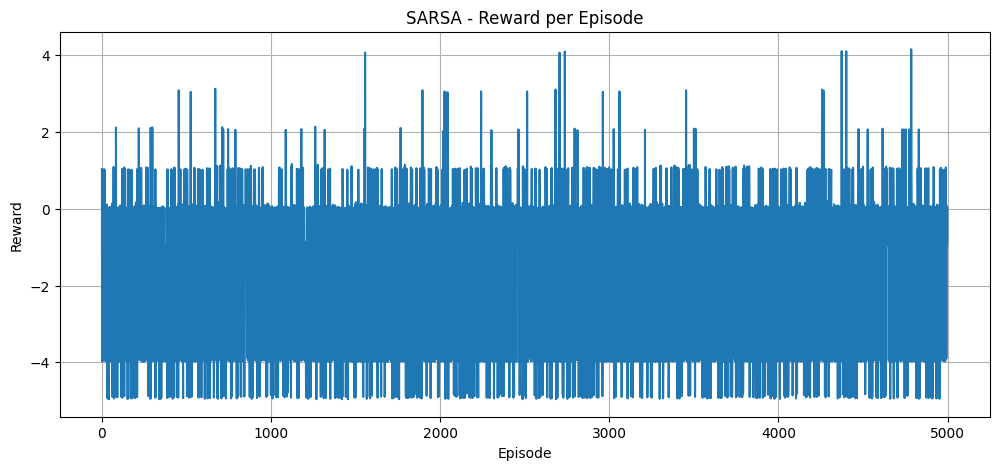

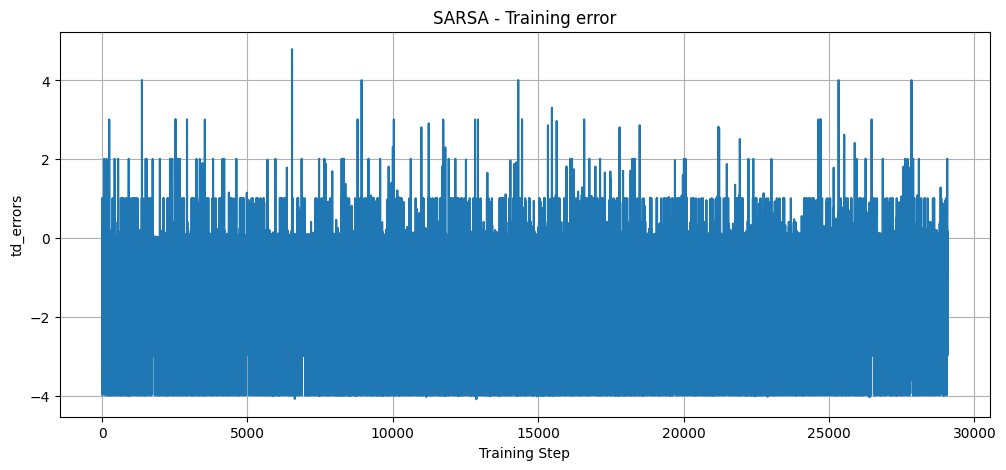

In [ ]:
# ===== PLOTS =====

# Reward plot
plt.figure(figsize=(12,5))
plt.plot(SARSA_rewards)
plt.title("SARSA - Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()
plt.show()

# Loss plot
if len(td_errors) > 0:
    plt.figure(figsize=(12,5))
    plt.plot(td_errors)
    plt.title("SARSA - Training error")
    plt.xlabel("Training Step")
    plt.ylabel("td_errors")
    plt.grid()
    plt.show()

In [ ]:
win_rate, avg_reward = evaluate(env, Q)
print(f"Win rate SARSA: {win_rate:.2}")
print(f"Average reward SARSA: {avg_reward:.2}")

/content/gym-idsgame/gym_idsgame/envs/idsgame_env.py:210: UserWarning: WARN: You are calling 'step()' even though this environment has already returned done = True. You should always call 'reset()' once you receive 'done = True' -- any further steps are undefined behavior.
  gym.logger.warn(


Win rate SARSA: 0.52
Average reward SARSA: -1.2e+01


#Parte 2: implementazione DDQN per confrontare una politica neurale con la baseline tabellare SARSA.

In [ ]:
# re-import necessari al fine rendere funzionante lo script di training
import sys
import gym_idsgame
from gym_idsgame.agents.bot_agents.attack_maximal_value_bot_agent import AttackMaximalValueBotAgent

In [ ]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


###Nel rispetto delle line guida del progetto, si è implemtata l'opzione di scegliere diversi tipi di attacco in base al test che si vuole effettuare:
settando do_MaximalAttack = True --> viene usato l'attaccante fonito dal repo GIT chiamato "AttackMaximalValueBotAgent".
Se do_MaximalAttack = False, viene usato l'attaccatnte fonito dal repo GIT chiamato "RandomAttackBotAgent".

In [ ]:
do_MaximalAttack = False

In [ ]:
# Verifica della dimensione dell'osservazione e del numero di azioni disponibili, necessaria per definire input e output della rete.
print(obs.shape)
print(obs.flatten().shape)
print(env.defender_action_space)
print(env.defender_action_space.n)

(4, 10)
(40,)
Discrete(20)
20


E' stato deciso di usare una rete fully-connected semplice: scelta adatta perché lo stato è rappresentato come vettore numerico flat. Lo strato di input riceve il vettore di stato, mentre lo strato di output produce un Q-value per ciascuna azione disponibile. In particolare:
- state_dim = 40: lo stato viene rappresentato come vettore flat di 40 caratteristiche, ottenute dalla flattenizzazione dell'osservazione dell'ambiente.
- action_dim = 20: il defender dispone di 20 azioni possibili, quindi la rete produce un Q-value per ciascuna azione.

In [ ]:
# ===== Q-NETWORK =====

state_dim = 40
action_dim = 20

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128), # Primo strato lineare: trasforma l'input dello stato in una rappresentazione più ricca.
            nn.ReLU(),
            nn.Linear(128, 128), # Secondo strato nascosto per apprendere combinazioni non lineari delle feature.
            nn.ReLU(),
            nn.Linear(128, action_dim) # Strato di output: produce un Q-value per ciascuna azione disponibile.
        )

    def forward(self, x):
        return self.net(x)

# online e target network
online_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)

target_net.load_state_dict(online_net.state_dict())
target_net.eval()

print(online_net)

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=40, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=20, bias=True)
  )
)


Replay buffer per decorrelare le esperienze e rendere il training più stabile.

In [ ]:
# Struttura dati per memorizzare le transizioni dell'esperienza passata.
# ===== REPLAY BUFFER =====
class ReplayBuffer:
    def __init__(self, capacity): # Inizializza il buffer con una capacità massima fissata.
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done): # Salva una transizione completa nel buffer.
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size): # Estrae un batch casuale di transizioni dal buffer.
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Conversione delle componenti del batch in array NumPy.:
        states = np.array(states, dtype=np.float32)
        next_states = np.array(next_states, dtype=np.float32)
        actions = np.array(actions, dtype=np.int64)
        rewards = np.array(rewards, dtype=np.float32)
        dones = np.array(dones, dtype=np.float32)

        # Conversione finale in tensori PyTorch e spostamento sul device:
        return (
        torch.from_numpy(states).to(device),
        torch.from_numpy(actions).to(device),
        torch.from_numpy(rewards).to(device),
        torch.from_numpy(next_states).to(device),
        torch.from_numpy(dones).to(device)
    )

    def __len__(self):
        return len(self.buffer)


# Creazione di un replay buffer di test per verificarne il corretto funzionamento.
buffer = ReplayBuffer(1000)
print("ReplayBuffer creato correttamente.")

ReplayBuffer creato correttamente.


In [ ]:
# ===== HYPERPARAMETERS + ACTION SELECTION =====

learning_rate = 1e-3
gamma = 0.99 # Fattore di sconto per bilanciare ricompense immediate e future.
batch_size = 64 # aumentato per cercare di eliminare rumore dovuto alla randomicità degli attacchi
buffer_capacity = 10000
min_buffer_size = 1500
target_update_freq = 200

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.99 # aumentato per rallentare il decadimento e aumentare la possibilità di eplorazione (dovuto alla randomicità del problema)

optimizer = optim.Adam(online_net.parameters(), lr=learning_rate) # Ottimizzatore Adam per aggiornare i pesi della rete online durante il training.

replay_buffer = ReplayBuffer(buffer_capacity)

# Selezione dell'azione tramite politica epsilon-greedy:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(action_dim)
    # Altrimenti lo stato viene convertito in tensore e passato nella rete online:
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        q_values = online_net(state_tensor)

    return q_values.argmax().item()


print("Setup DDQN completato.")

Setup DDQN completato.


Il processo adottato è il seguente:
- si aggiornano pesi della target network in modo soft per rendere l'apprendimento più stabile, evitando cambiamenti bruschi nei target Q e riducendo le oscillazioni durante il training.
- Se il replay buffer contiene ancora poche esperienze, si rimanda il training, evitando di aggiornare la rete su campioni troppo pochi o poco rappresentativi, migliorando la stabilità iniziale dell'apprendimento.

In [ ]:
def soft_update(target_net, online_net, tau=0.005):
    for target_param, online_param in zip(target_net.parameters(), online_net.parameters()):
        target_param.data.copy_(
            tau * online_param.data + (1.0 - tau) * target_param.data
        )

In [ ]:
# ===== TRAIN STEP (DOUBLE DQN) =====

def train_step():
    if len(replay_buffer) < min_buffer_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    q_values = online_net(states) # Calcolo dei Q-value correnti per tutti gli stati del minibatch
    q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze(1) # Selezione dei Q-value corrispondenti alle azioni realmente compiute

    # ===== DOUBLE DQN =====

# La rete online seleziona l'azione migliore nel prossimo stato
    next_q_online = online_net(next_states)
    next_actions = next_q_online.argmax(dim=1)

# La rete target valuta l'azione selezionata dalla rete online
    next_q_target = target_net(next_states)
    next_q_value = next_q_target.gather(1, next_actions.unsqueeze(1)).squeeze(1)

    target = rewards + gamma * next_q_value * (1 - dones)

# Calcolo della loss come errore quadratico medio tra Q stimati e target
    loss = nn.MSELoss()(q_value, target.detach())

# Azzeramento dei gradienti accumulati prima del nuovo aggiornamento
    optimizer.zero_grad()
    loss.backward() # Calcolo della retropropagazione della loss
    optimizer.step()

    return loss.item()


print("Train step DDQN definito correttamente.")

Train step DDQN definito correttamente.


In [ ]:
# ===== DDQN TRAINING LOOP =====

if do_MaximalAttack:
  attacker = AttackMaximalValueBotAgent(game_config, env)
  print("attacker inizializzato con AttackMaximalValueBotAgent")
else:
   print("attacker inizializzato con RandomAttackBotAgent")


num_episodes = 5000
max_steps = 30

episode_rewards = []
losses = []

global_step = 0

for episode in range(num_episodes):

    obs, _ = env.reset()
    state = obs.flatten().astype(np.float32) / 10.0

    total_reward = 0
    prev_hacked = 0

    for step in range(max_steps):

        # Selezione azione defender
        action = select_action(state, epsilon) # Selezione dell'azione tramite politica epsilon-greedy.


        # Attaccante random esterno dall'ambiente GIT:
        # attack_action = env.attacker_action_space.sample()

        attacker.convert_local_attacker_action_to_global(0,obs)
        attack_action = attacker.action

        next_obs, reward, terminated, truncated, _ = env.step((attack_action, action))
        obs = next_obs
        done = terminated or truncated

        # --- reward personalizzato ----------------------------------------
        base_reward = reward[0]
        win_reward = 0
        if env.state.hacked:
            win_reward = -3.0   # perdita immediata
        elif not env.state.hacked and terminated:
            win_reward = +1.0   # vittoria finale
        # shaping intermedio
        survival_bonus = 0.01
        reward = base_reward + win_reward + survival_bonus
        # ------------------------------------------------------------------

        # Salvataggio della transizione nel replay buffer per riutilizzare esperienze passate e addestrare la rete in modo off-policy
        next_state = next_obs.flatten() / 10.0

        # Salviamo nel replay buffer
        replay_buffer.push(state, action, reward, next_state, done)

        # Training step
        loss = train_step()
        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

        global_step += 1

        # Aggiornamento target network
        soft_update(target_net, online_net, tau=0.005)

        if done:
            episode_rewards.append(total_reward)
            break

    # Riduzione graduale di epsilon per passare progressivamente dall'esplorazione allo sfruttamento
    epsilon = max(epsilon_min, epsilon * epsilon_decay)



    if episode % 500 == 0:
        print(f"Episode {episode}, Reward: {total_reward:.2f}, Epsilon: {epsilon:.3f}")

print("Training DDQN completato.")

attacker inizializzato con RandomAttackBotAgent
Episode 0, Reward: 0.04, Epsilon: 0.990
Episode 500, Reward: 0.07, Epsilon: 0.050
Episode 1000, Reward: -3.96, Epsilon: 0.050
Episode 1500, Reward: 0.03, Epsilon: 0.050
Episode 2000, Reward: 0.01, Epsilon: 0.050
Episode 2500, Reward: -4.88, Epsilon: 0.050
Episode 3000, Reward: 0.06, Epsilon: 0.050
Episode 3500, Reward: 0.02, Epsilon: 0.050
Episode 4000, Reward: -0.92, Epsilon: 0.050
Episode 4500, Reward: 0.01, Epsilon: 0.050
Training DDQN completato.


Per la parte di evalaution, viene utilizzata la policy greedy appresa senza esplorazione.
Anche qui, la vittoria viene conteggiata solo se l'episodio termina senza compromissione del defender.



In [ ]:
# ===== EVALUATION =====

if do_MaximalAttack:
  attacker = AttackMaximalValueBotAgent(game_config, env)
  print("attacker inizializzato con AttackMaximalValueBotAgent")
else:
   print("attacker inizializzato con RandomAttackBotAgent")


def evaluate_ddqn(env, episodes=300, max_steps=30):

    wins = 0
    total_reward = 0

    for ep in range(episodes):
        obs, _ = env.reset()
        state = obs.flatten().astype(np.float32) / 10.0

        for step in range(max_steps):

            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                action = online_net(state_tensor).argmax().item()

            attacker.convert_local_attacker_action_to_global(0, obs)
            attack_action = attacker.action

            next_obs, reward, terminated, truncated, _ = env.step((attack_action, action))
            obs = next_obs
            done = terminated or truncated

            reward = float(reward[0])
            total_reward += reward

            state = next_obs.flatten() / 10.0

            if done:
                if env.state.hacked == False:
                    wins += 1
                break

    return wins / episodes, total_reward / episodes


eval_env = IdsGameRandomAttackV21Env()
win_rate_DDQN, avg_reward_DDQN = evaluate_ddqn(
    eval_env,
    episodes=200,
    max_steps=20
)

print("DDQN Win Rate:", win_rate_DDQN)
print("DDQN Avg Reward:", avg_reward_DDQN)

attacker inizializzato con RandomAttackBotAgent
DDQN Win Rate: 0.585
DDQN Avg Reward: -0.525


Per valutare quale algoritmo apprende una policy più efficace, si pensato di graficare un confronto tra i reward ottenuti da SARSA e DDQN.
Per valutare la stabilità dell'aggiornamento nei due approcci si è invece graficato errore TD di SARSA vs loss del DDQN.


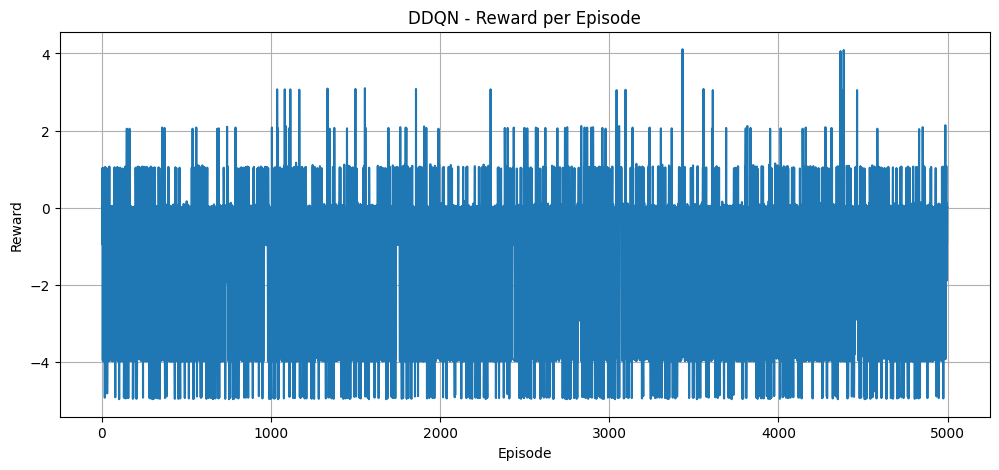

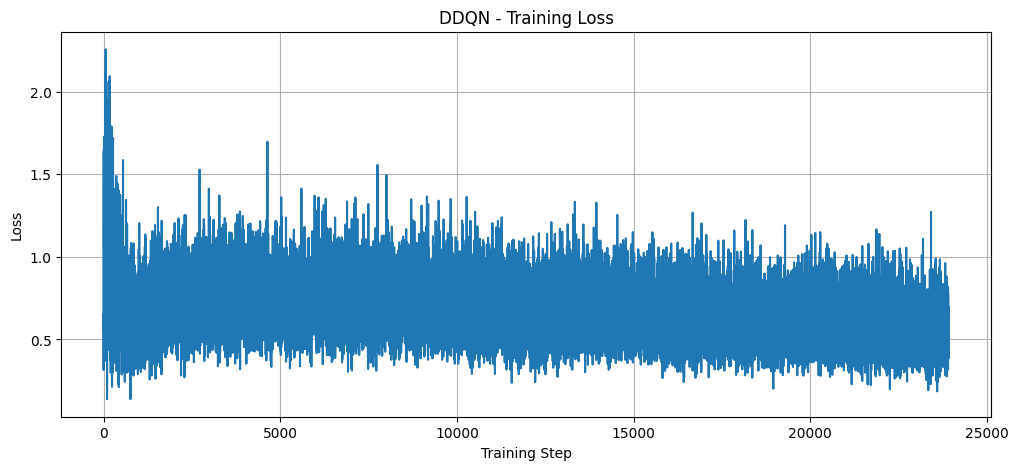

In [ ]:
# ===== PLOTS =====

# Reward plot
plt.figure(figsize=(12,5))
plt.plot(episode_rewards)
plt.title("DDQN - Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()
plt.show()

# Loss plot
if len(losses) > 0:
    plt.figure(figsize=(12,5))
    plt.plot(losses)
    plt.title("DDQN - Training Loss")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

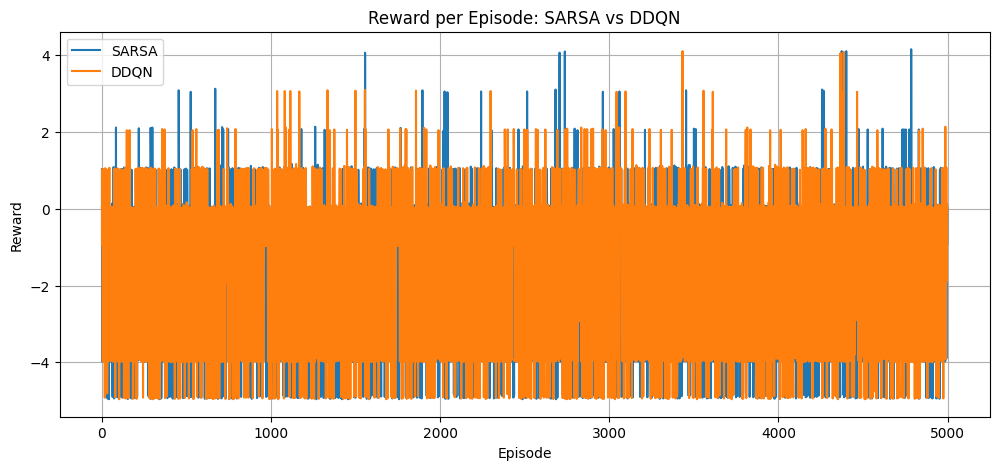

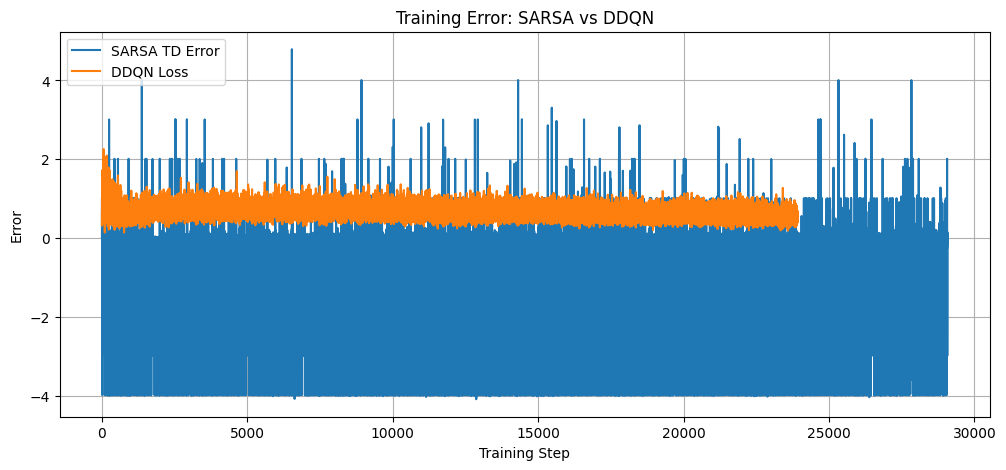

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(SARSA_rewards, label="SARSA")
plt.plot(episode_rewards, label="DDQN")

plt.title("Reward per Episode: SARSA vs DDQN")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12,5))

plt.plot(td_errors, label="SARSA TD Error")
plt.plot(losses, label="DDQN Loss")

plt.title("Training Error: SARSA vs DDQN")
plt.xlabel("Training Step")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

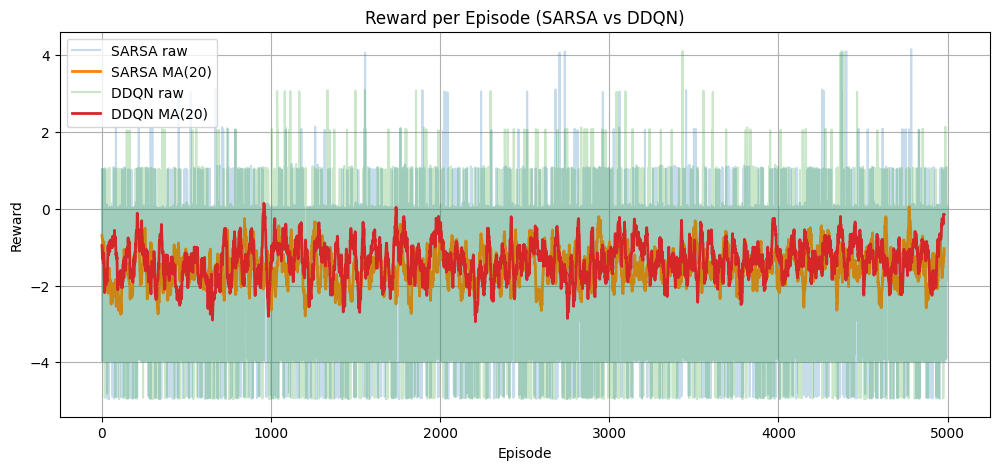

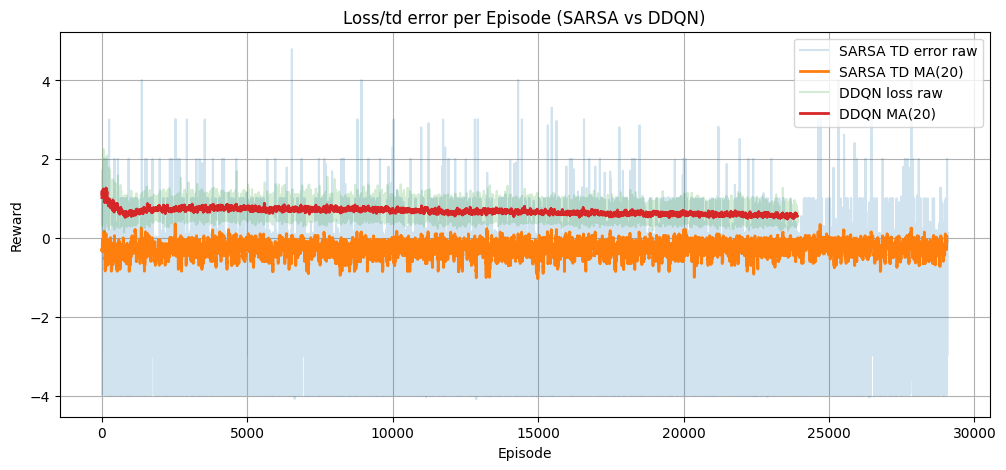

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def moving_average(x, window=20):
    x = np.array(x, dtype=np.float32)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')


# =========================
# SARSA vs DDQN - REWARD
# =========================

window = 20

sarsa_ma = moving_average(SARSA_rewards, window)
ddqn_ma = moving_average(episode_rewards, window)  # DDQN rewards

plt.figure(figsize=(12,5))

plt.plot(SARSA_rewards, alpha=0.25, label="SARSA raw")
plt.plot(np.arange(len(sarsa_ma)), sarsa_ma, linewidth=2, label=f"SARSA MA({window})")

plt.plot(episode_rewards, alpha=0.25, label="DDQN raw")
plt.plot(np.arange(len(ddqn_ma)), ddqn_ma, linewidth=2, label=f"DDQN MA({window})")

plt.title("Reward per Episode (SARSA vs DDQN)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.show()


# =========================
# TD ERROR / LOSS
# =========================

if len(td_errors) > 0:

    td_ma = moving_average(td_errors, window)
    loss_ma = moving_average(losses, window)

    plt.figure(figsize=(12,5))

    plt.plot(td_errors, alpha=0.2, label="SARSA TD error raw")
    plt.plot(np.arange(len(td_ma)), td_ma, linewidth=2, label=f"SARSA TD MA({window})")

    plt.plot(losses, alpha=0.2, label="DDQN loss raw")
    plt.plot(np.arange(len(loss_ma)), loss_ma, linewidth=2, label=f"DDQN MA({window})")

    plt.title("Loss/td error per Episode (SARSA vs DDQN)")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid()
    plt.show()


# Conclusioni:

- SARSA: L’algoritmo SARSA è stato in grado di apprendere una policy parzialmente efficace, come mostrato dal win rate pari a 0.6, che indica una percentuale di successo del defender sino al 60% a seconda delle iterazioni effettuate. Tuttavia, il valore medio della ricompensa presenta valori negativi, evidenziando che il comportamento dell’agente resta complessivamente instabile e poco soddisfacente dal punto di vista della qualità dell’apprendimento.

  L’andamento delle SARSA_rewards mostra infatti una forte variabilità tra episodi, con numerosi valori negativi e solo sporadici episodi positivi. Questo suggerisce che l’agente non ha ancora raggiunto una politica pienamente robusta, ma ha comunque acquisito una capacità limitata di contrastare l’attaccante in alcune condizioni specifiche.

  Anche i td_errors confermano questa interpretazione: inizialmente presentano valori più elevati e molto variabili, mentre successivamente tendono a ridursi e a stabilizzarsi su valori più piccoli. Questo comportamento indica che il processo di aggiornamento converge parzialmente, ma senza eliminare del tutto l’instabilità dell’apprendimento, probabilmente dovuta alla variabilità degli attacchi

  In conclusione, SARSA mostra una capacità di apprendimento discreta, ma non completamente soddisfacente. Il risultato suggerisce che l’algoritmo riesce a migliorare rispetto a un comportamento casuale, ma fatica a produrre una strategia realmente robusta e stabile in un ambiente adversarial come quello considerato.

- DDQN con maximal attack: Il modello DDQN mostra prestazioni complessivamente migliori rispetto a SARSA, soprattutto in termini di ricompensa media finale. In particolare, con attaccante AttackMaximalValueBotAgent, il modello ottiene un win rate pari a 0.62, quindi leggermente superiore a quello osservato con SARSA, e soprattutto una average reward pari a -0.47, molto più vicina allo zero rispetto al valore negativo ottenuto da SARSA.

  Questo risultato suggerisce che il DDQN è riuscito ad apprendere una policy più efficace e più stabile nel gestire l’ambiente avversariale. L’andamento di episode_rewards mostra infatti episodi alternati tra esiti positivi e negativi, ma con una tendenza complessiva meno penalizzante rispetto a SARSA. Anche la loss tende a stabilizzarsi nel tempo, indicando un apprendimento progressivamente più consistente.

  Va tuttavia considerato che, trattandosi di un ambiente stocastico e di un agente avversario, i valori finali possono variare da un run all’altro. Nonostante questa variabilità, il comportamento generale del DDQN resta più favorevole: il modello riesce a ottenere una percentuale di successo leggermente superiore e, soprattutto, a mantenere una ricompensa media molto più vicina a zero, segno di una migliore capacità di adattamento.

  In conclusione: il DDQN ha ottenuto un win rate con valori sino al 62% e una ricompensa media pari a -0.47, mostrando prestazioni migliori rispetto a SARSA. In particolare, il valore medio della reward risulta molto più vicino allo zero, suggerendo una policy più efficace e stabile. Sebbene i risultati possano variare tra esecuzioni diverse a causa della natura stocastica dell’ambiente e dell’attaccante, il comportamento complessivo del DDQN appare più robusto rispetto a quello dell’algoritmo SARSA.

- DDQN con attaccante randommico: in questo scenario viene raggiunto un win rate pari a 0.65 e una reward media pari a -0.485. I risultati indicano una capacità di adattamento discreta e un comportamento complessivamente migliore rispetto allo scenario più avversarial, anche se l’andamento delle reward resta variabile e la policy non appare ancora completamente stabile.

# Prospettive future / di mmiglioramento

Nel complesso, i test svolti mostrano che le prestazioni dell’agente cambiano in modo significativo a seconda della strategia adottata dall’attaccante. Per questo, in lavori futuri sarebbe utile curare meglio il tuning degli iperparametri, così da rendere l’addestramento più stabile e migliorare la qualità dell’apprendimento. Un altro aspetto importante riguarda la generalizzazione: addestrare il defender contro avversari diversi e non solo su un singolo tipo di attacco permetterebbe di valutarne meglio la robustezza e di ottenere una policy più solida in scenari nuovi o meno prevedibili. In questa direzione, potrebbe essere interessante estendere il lavoro a un contesto di training rispetto all'avversario, con una maggiore varietà di tipologie di avversari durante l’addestramento e la valutazione.